<h2>Modelling: Future Price Direction

The ML aspects of this project will be divided into two separate parts: 
- Predicting future price direction and,
- Predicting future price volatilty

It's very dificult predicting exact future price but if future direction and volatility can be predicted, an agent can take this information and size a position accordingly.

I want to create a model which takes in a sequence of prices and outputs a probability of the next price being higher or lower than the last (or the average) of the sequence.

One concern I have is if the day to day prices are too noisy that the next predicted value may not be particularly accurate i.e. it may also be noise. The model may have a low conviction in a decisive price movement. This could be overcome potentially by having the model take in some data and then say which the direction the price may be 1 week / 1 month from now, with an associated probability. This combined with a predicted volatility (to be modelled separately) may contain better information.

Furthermore, just price quotes may not be enough. It may be necessary to add price indicators such as RSI, MACD, and moving averages.

In [1]:
import sys
from pathlib import Path

PROJ_ROOT = Path().resolve().parents[0]
project_root = str(PROJ_ROOT)
sys.path.insert(0, project_root)

In [2]:
DATA_DIR = PROJ_ROOT / "data"
RAW_DATA_DIR = DATA_DIR / "raw"
RAW_DATA_PATH = RAW_DATA_DIR / "btcusd_data.pkl"
print(RAW_DATA_PATH)

C:\Users\cochr\Data Science Projects\vlXsnPPgKKnWqEJB\data\raw\btcusd_data.pkl


In [3]:
import pickle
import numpy as np
import pandas as pd

<h3> Logistic Regression

In [4]:
# Only load pickle files from a trusted source; unpickling can execute code.
with RAW_DATA_PATH.open("rb") as file:
    raw_data = pickle.load(file)

raw_data.head()

Price,Date,Close,High,Low,Open,Volume
0,2014-09-17,457.334015,468.174011,452.421997,465.864014,21056800
1,2014-09-18,424.440002,456.859985,413.104004,456.859985,34483200
2,2014-09-19,394.795990,427.834991,384.532013,424.102997,37919700
3,2014-09-20,408.903992,423.295990,389.882996,394.673004,36863600
4,2014-09-21,398.821014,412.425995,393.181000,408.084991,26580100


We will take 'Close' as the current price. From here, we need to create columns that offset the Close value to a given interval in the future e.g. 1 day, 5 day, 10 day, then return a binary value saying if it is higher (1) or lower (0) than the Close of the current day.

*<h4>1-day Data</h4>*

<h4>Feature Creation</h4>

Add column that contains a binary value which says whether the price 1-day into the future is larger or smaller than the current price (direction)

In [5]:
raw_data["Close_1"] = raw_data["Close"].shift(-1)
raw_data.head()

Price,Date,Close,High,Low,Open,Volume,Close_1
0,2014-09-17,457.334015,468.174011,452.421997,465.864014,21056800,424.440002
1,2014-09-18,424.440002,456.859985,413.104004,456.859985,34483200,394.795990
2,2014-09-19,394.795990,427.834991,384.532013,424.102997,37919700,408.903992
3,2014-09-20,408.903992,423.295990,389.882996,394.673004,36863600,398.821014
4,2014-09-21,398.821014,412.425995,393.181000,408.084991,26580100,402.152008


In [6]:
raw_data["Direction_1"] = np.where(raw_data["Close_1"] > raw_data["Close"], 1, 0)
raw_data.head()

Price,Date,Close,High,Low,Open,Volume,Close_1,Direction_1
0,2014-09-17,457.334015,468.174011,452.421997,465.864014,21056800,424.440002,0
1,2014-09-18,424.440002,456.859985,413.104004,456.859985,34483200,394.795990,0
2,2014-09-19,394.795990,427.834991,384.532013,424.102997,37919700,408.903992,1
3,2014-09-20,408.903992,423.295990,389.882996,394.673004,36863600,398.821014,0
4,2014-09-21,398.821014,412.425995,393.181000,408.084991,26580100,402.152008,1


Function to carry this out arbitrarily:

In [42]:
def add_direction(data: pd.DataFrame, shift: int = 1, price: str = "Close") -> pd.DataFrame:
    """Add an integer label: 1 if the future price is higher, otherwise 0.

    Rows without a future price are left as missing. Example:
    `data = add_direction(raw_data, shift=5)`.
    """
    if shift < 1:
        raise ValueError("shift must be a positive integer")

    result = data.copy()
    future_price = result[price].shift(-shift)
    result[f"Direction_{shift}"] = (
        (future_price > result[price]).astype("Int64").where(future_price.notna())
    )
    return result

In [8]:
# Then drop Close_1, Date (no useful information):
raw_data = raw_data.drop(columns=["Close_1", "Date"])
raw_data.head()

Price,Close,High,Low,Open,Volume,Direction_1
0,457.334015,468.174011,452.421997,465.864014,21056800,0
1,424.440002,456.859985,413.104004,456.859985,34483200,0
2,394.795990,427.834991,384.532013,424.102997,37919700,1
3,408.903992,423.295990,389.882996,394.673004,36863600,0
4,398.821014,412.425995,393.181000,408.084991,26580100,1


<h5>Additional Information: Price Indicators:

Lot's of technical trading relies on indicators other than the price. They include:
- Relative Strength Index (RSI)
- Moving Average Convergence-Divergence (MACD)
- Moving Averages
- Intraday Range (IDR)
- Average True Range (ATR)

*RSI:*

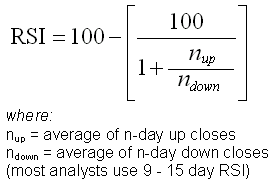

*MACD:*

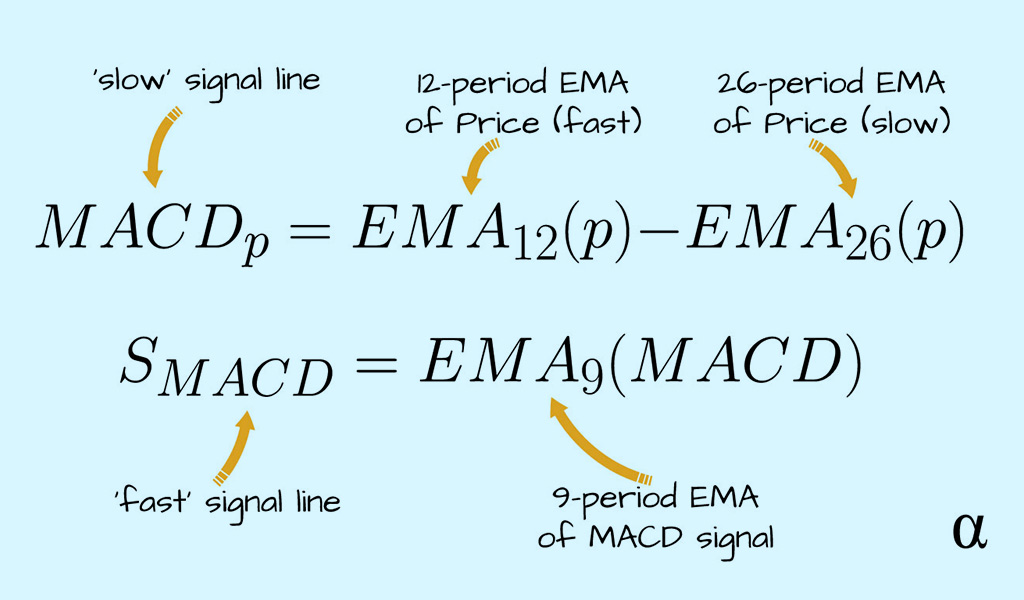

The difference between slow and fast MACD signal lines gives the histogram commonly seen on trading charts. It can help spot price reversals.
(This is the 3rd part of the calculation, but it doesn't necessarily contain new info as it is the difference between two values already quoted. May be useful when feature selection is required...)

*Moving Averages:*
- Simple (SMA):
    - Sum of close/current prices divided by the number of observations where each observation contributes an equal weight
- Exponential (EMA):
    - Similar to SMA except a greater weighting is applied to the most recent observations.

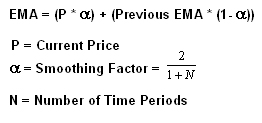

*IDR and ATR:*

- IDR is simply High - Low.
- ATR is a smoothed average of IDR over a set period.

The key thing to watch out for is for the propensity (if present) of any of these indicators to leak data. They all use backward facing data so this shouldn'r be an issue.

A function(s) to add these indicators as features to each observation:

In [9]:
def add_SMA(data: pd.DataFrame, n: int = 7, price: str = "Close") -> pd.DataFrame:
    """Add an n-period simple moving average.

    Example: `data = add_SMA(raw_data, n=7)`
    """
    result = data.copy()
    result[f"SMA_{n}"] = result[price].rolling(window=n, min_periods=n).mean() #1
    return result


def add_EMA(data: pd.DataFrame, n: int = 7, price: str = "Close") -> pd.DataFrame:
    """Add an n-period exponential moving average.

    Example: `data = add_EMA(raw_data, n=7)`
    """
    result = data.copy()
    result[f"EMA_{n}"] = result[price].ewm(span=n, min_periods=n, adjust=False).mean() #1
    return result


def add_ranges(data: pd.DataFrame, n: int = 4, low: str = "Low", high: str = "High") -> pd.DataFrame:
    """Add intraday range (IDR) and n-period average true range (ATR).

    Example: `data = add_ranges(raw_data, n=4)`
    """
    result = data.copy()
    previous_close = result["Close"].shift(1)
    result["IDR"] = result[high] - result[low] #1
    true_range = pd.concat(
        [
            result[high] - result[low],
            (result[high] - previous_close).abs(),
            (result[low] - previous_close).abs(),
        ],
        axis=1,
    ).max(axis=1)
    result[f"ATR_{n}"] = true_range.rolling(window=n, min_periods=n).mean() #1
    return result


def add_RSI(data: pd.DataFrame, n: int = 14) -> pd.DataFrame:
    """Add an n-period RSI calculated with Wilder-style exponential averages.

    Example: `data = add_RSI(raw_data, n=14)`
    """
    result = data.copy()
    change = result["Close"].diff()
    average_gain = change.clip(lower=0).ewm(alpha=1 / n, min_periods=n, adjust=False).mean()
    average_loss = -change.clip(upper=0).ewm(alpha=1 / n, min_periods=n, adjust=False).mean()

    rsi = 100 - 100 / (1 + average_gain / average_loss)
    rsi = rsi.mask((average_loss == 0) & (average_gain > 0), 100)
    rsi = rsi.mask((average_loss == 0) & (average_gain == 0), 50)
    result[f"RSI_{n}"] = rsi #1
    return result


def add_MACD(data: pd.DataFrame) -> pd.DataFrame:
    """Add MACD (12/26), its 9-period signal line, and the histogram.

    Example: `data = add_MACD(raw_data)`
    """
    result = data.copy()
    close = result["Close"]
    fast_ema = close.ewm(span=12, min_periods=12, adjust=False).mean()
    slow_ema = close.ewm(span=26, min_periods=26, adjust=False).mean()
    result["MACD"] = fast_ema - slow_ema #1
    result["MACD_signal"] = result["MACD"].ewm(span=9, min_periods=9, adjust=False).mean() #2
    result["MACD_hist"] = result["MACD"] - result["MACD_signal"] #3
    return result

In [10]:
data = add_SMA(data = raw_data)
data = add_EMA(data = data)
data = add_ranges(data = data)
data = add_RSI(data = data)
data = add_MACD(data = data)
data.head()

Price,Close,High,Low,Open,Volume,Direction_1,SMA_7,EMA_7,IDR,ATR_4,RSI_14,MACD,MACD_signal,MACD_hist
0,457.334015,468.174011,452.421997,465.864014,21056800,0,NaN,NaN,15.752014,NaN,NaN,NaN,NaN,NaN
1,424.440002,456.859985,413.104004,456.859985,34483200,0,NaN,NaN,43.755981,NaN,NaN,NaN,NaN,NaN
2,394.795990,427.834991,384.532013,424.102997,37919700,1,NaN,NaN,43.302979,NaN,NaN,NaN,NaN,NaN
3,408.903992,423.295990,389.882996,394.673004,36863600,0,NaN,NaN,33.412994,34.174500,NaN,NaN,NaN,NaN
4,398.821014,412.425995,393.181000,408.084991,26580100,1,NaN,NaN,19.244995,35.047745,NaN,NaN,NaN,NaN


In [11]:
data.tail()

Price,Close,High,Low,Open,Volume,Direction_1,SMA_7,EMA_7,IDR,ATR_4,RSI_14,MACD,MACD_signal,MACD_hist
4393,84458.085938,85126.109375,84121.328125,84412.718750,19386591468,0,84919.532366,83882.711789,1004.781250,1420.246094,65.085842,2436.591197,2216.512665,220.078532
4394,83502.609375,84972.664062,82570.718750,84454.117188,42589028679,1,84476.631696,83787.686186,2401.945312,1528.330078,60.920863,2309.066922,2235.023516,74.043406
4395,83622.429688,84511.281250,82739.093750,83500.320312,28029782264,0,84112.367188,83746.372061,1772.187500,1455.246094,61.255696,2192.398904,2226.498594,-34.099690
4396,83553.851562,85599.804688,82927.875000,83621.398438,36290317874,1,83993.916295,83698.241936,2671.929688,1962.710938,60.933899,2070.537114,2195.306298,-124.769184
4397,83750.023438,84331.562500,83165.843750,83566.335938,29909526528,0,83904.053571,83711.187312,1165.718750,2002.945312,61.556056,1967.114527,2149.667944,-182.553417


Based on the time lag of some of the indicators there are a few NaN rows. These will have to be removed.

In [12]:
data = data.dropna().copy()
data.head()

Price,Close,High,Low,Open,Volume,Direction_1,SMA_7,EMA_7,IDR,ATR_4,RSI_14,MACD,MACD_signal,MACD_hist
33,382.845001,390.084015,378.252014,389.230988,16419000,1,389.398568,385.053349,11.832001,11.397491,36.470417,-3.112802,-7.666231,4.553430
34,386.475006,392.645996,380.834015,382.420990,14188900,0,387.342141,385.408763,11.811981,11.828239,38.000530,-2.514616,-6.635908,4.121292
35,383.157990,388.575989,382.248993,386.118011,11641300,0,385.682853,384.846070,6.326996,9.363243,37.120720,-2.281901,-5.765107,3.483206
36,358.416992,385.048004,356.446991,382.962006,26456900,0,382.234423,378.238800,28.601013,14.642998,31.299762,-4.047210,-5.421527,1.374317
37,358.345001,364.345001,353.304993,358.591003,15585700,0,378.603995,373.265351,11.040009,14.445000,31.284389,-5.389908,-5.415203,0.025295


In [13]:
data.shape

(4365, 14)

<h3>Data Splitting

In [22]:
# Separate X and y:
X = data.drop(columns=["Direction_1"])
y = data["Direction_1"]

In [23]:
from sklearn.model_selection import train_test_split

# Make sure to pass 'shuffle = False' to the function as we are dealing with temporal data:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

In [24]:
print(f"X_train shape:{X_train.shape}")
print(f"X_test shape:{X_test.shape}")
print(f"y_train shape:{y_train.shape}")
print(f"y_test shape:{y_test.shape}")


X_train shape:(3492, 13)
X_test shape:(873, 13)
y_train shape:(3492,)
y_test shape:(873,)


In [25]:
X_train.head()

Price,Close,High,Low,Open,Volume,SMA_7,EMA_7,IDR,ATR_4,RSI_14,MACD,MACD_signal,MACD_hist
33,382.845001,390.084015,378.252014,389.230988,16419000,389.398568,385.053349,11.832001,11.397491,36.470417,-3.112802,-7.666231,4.553430
34,386.475006,392.645996,380.834015,382.420990,14188900,387.342141,385.408763,11.811981,11.828239,38.000530,-2.514616,-6.635908,4.121292
35,383.157990,388.575989,382.248993,386.118011,11641300,385.682853,384.846070,6.326996,9.363243,37.120720,-2.281901,-5.765107,3.483206
36,358.416992,385.048004,356.446991,382.962006,26456900,382.234423,378.238800,28.601013,14.642998,31.299762,-4.047210,-5.421527,1.374317
37,358.345001,364.345001,353.304993,358.591003,15585700,378.603995,373.265351,11.040009,14.445000,31.284389,-5.389908,-5.415203,0.025295


Looking at this now when we extend the Direction_1 column to a longer period e.g the price direction n = 5,7 10 days from now (Direction_n), we will be able to make these datasets from the indicator-rich dataset just made here as none of these indicators were made using information in the Direction_1 column...

<h4>EDA and Feature Selection</h4>

Some feature selection techniques to carry out involving data with numerical features and categorical labels:
- Box and violin plots

- Correlation analysis
    - Point-biserial correlation

- Variance threshold

- Mutual information

- ANOVA F-test
    - Ordinary + Welch

- Logistic regression w/ L1/lasso regression

- Tukey's HSD

Something important to note is the features may have differing correlation between different labels. Here we have Direction_1 as the label, where it looks at the price one day ahead, but longer timeframes such as 5, 7, or 10 days ahead (not created yet) may output different results during feature selection.

In [29]:
features = list(X_train.columns)
# All features are numerical. Only the label is categorical.

In [28]:
# Create a 'new' variable containing X_train and y_train to be used as the EDA / feature selection dataset:
fs_data = X_train.copy()
fs_data['Direction_1'] = y_train
fs_data.head()

Price,Close,High,Low,Open,Volume,SMA_7,EMA_7,IDR,ATR_4,RSI_14,MACD,MACD_signal,MACD_hist,Direction_1
33,382.845001,390.084015,378.252014,389.230988,16419000,389.398568,385.053349,11.832001,11.397491,36.470417,-3.112802,-7.666231,4.553430,1
34,386.475006,392.645996,380.834015,382.420990,14188900,387.342141,385.408763,11.811981,11.828239,38.000530,-2.514616,-6.635908,4.121292,0
35,383.157990,388.575989,382.248993,386.118011,11641300,385.682853,384.846070,6.326996,9.363243,37.120720,-2.281901,-5.765107,3.483206,0
36,358.416992,385.048004,356.446991,382.962006,26456900,382.234423,378.238800,28.601013,14.642998,31.299762,-4.047210,-5.421527,1.374317,0
37,358.345001,364.345001,353.304993,358.591003,15585700,378.603995,373.265351,11.040009,14.445000,31.284389,-5.389908,-5.415203,0.025295,0


*Box and Violin Plots*

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

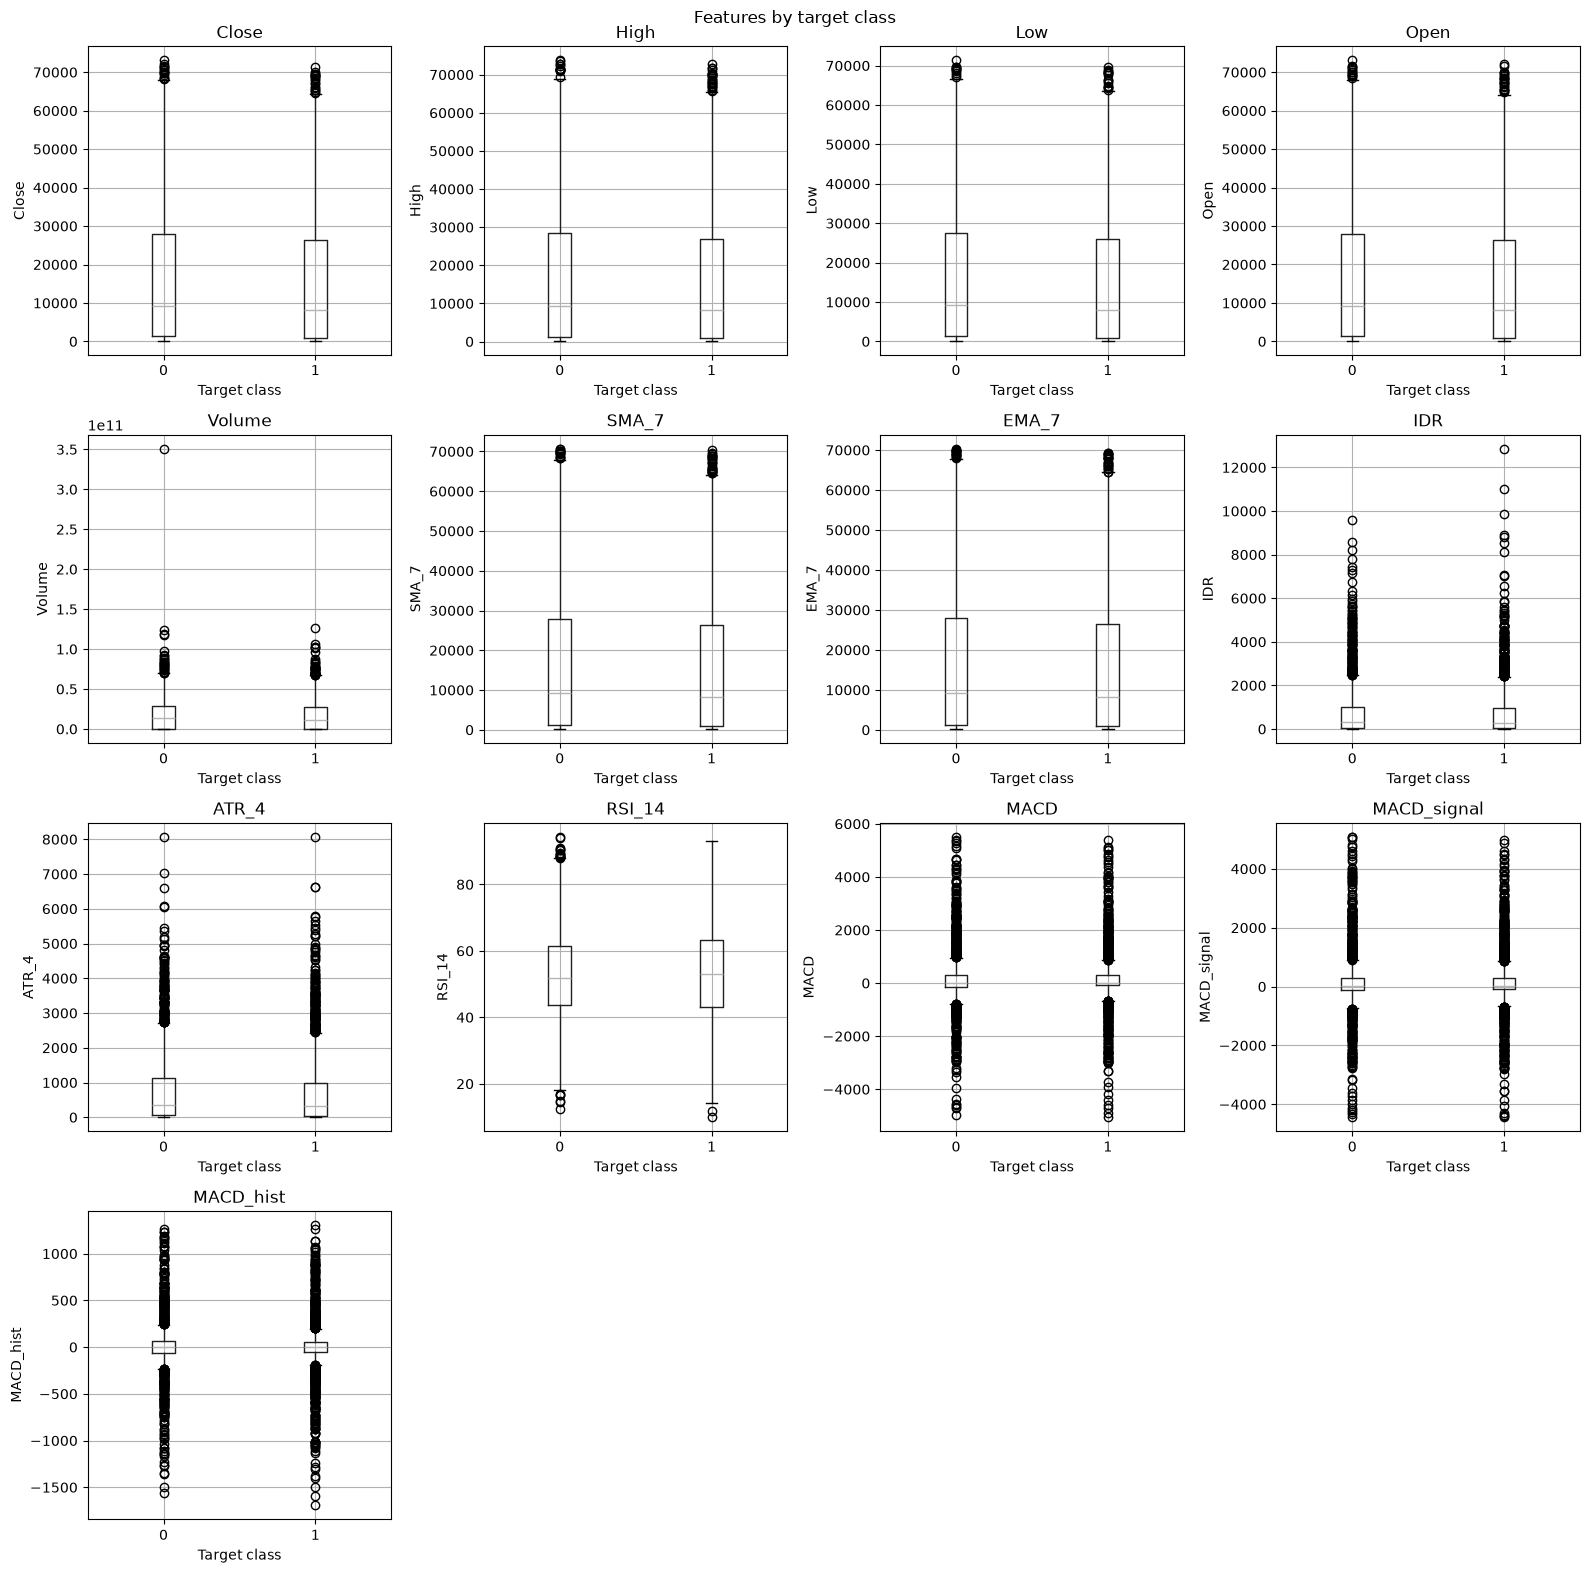

In [32]:
# Box plots:
ncols = 4
nrows = (len(features) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4 * nrows))
axes = np.asarray(axes).ravel()

for ax, feature in zip(axes, features):
    fs_data.boxplot(column=feature, by="Direction_1", ax=ax)
    ax.set_title(feature)
    ax.set_xlabel("Target class")
    ax.set_ylabel(feature)

for ax in axes[len(features):]:
    ax.set_visible(False)

fig.suptitle("Features by target class")
fig.tight_layout()
plt.show()

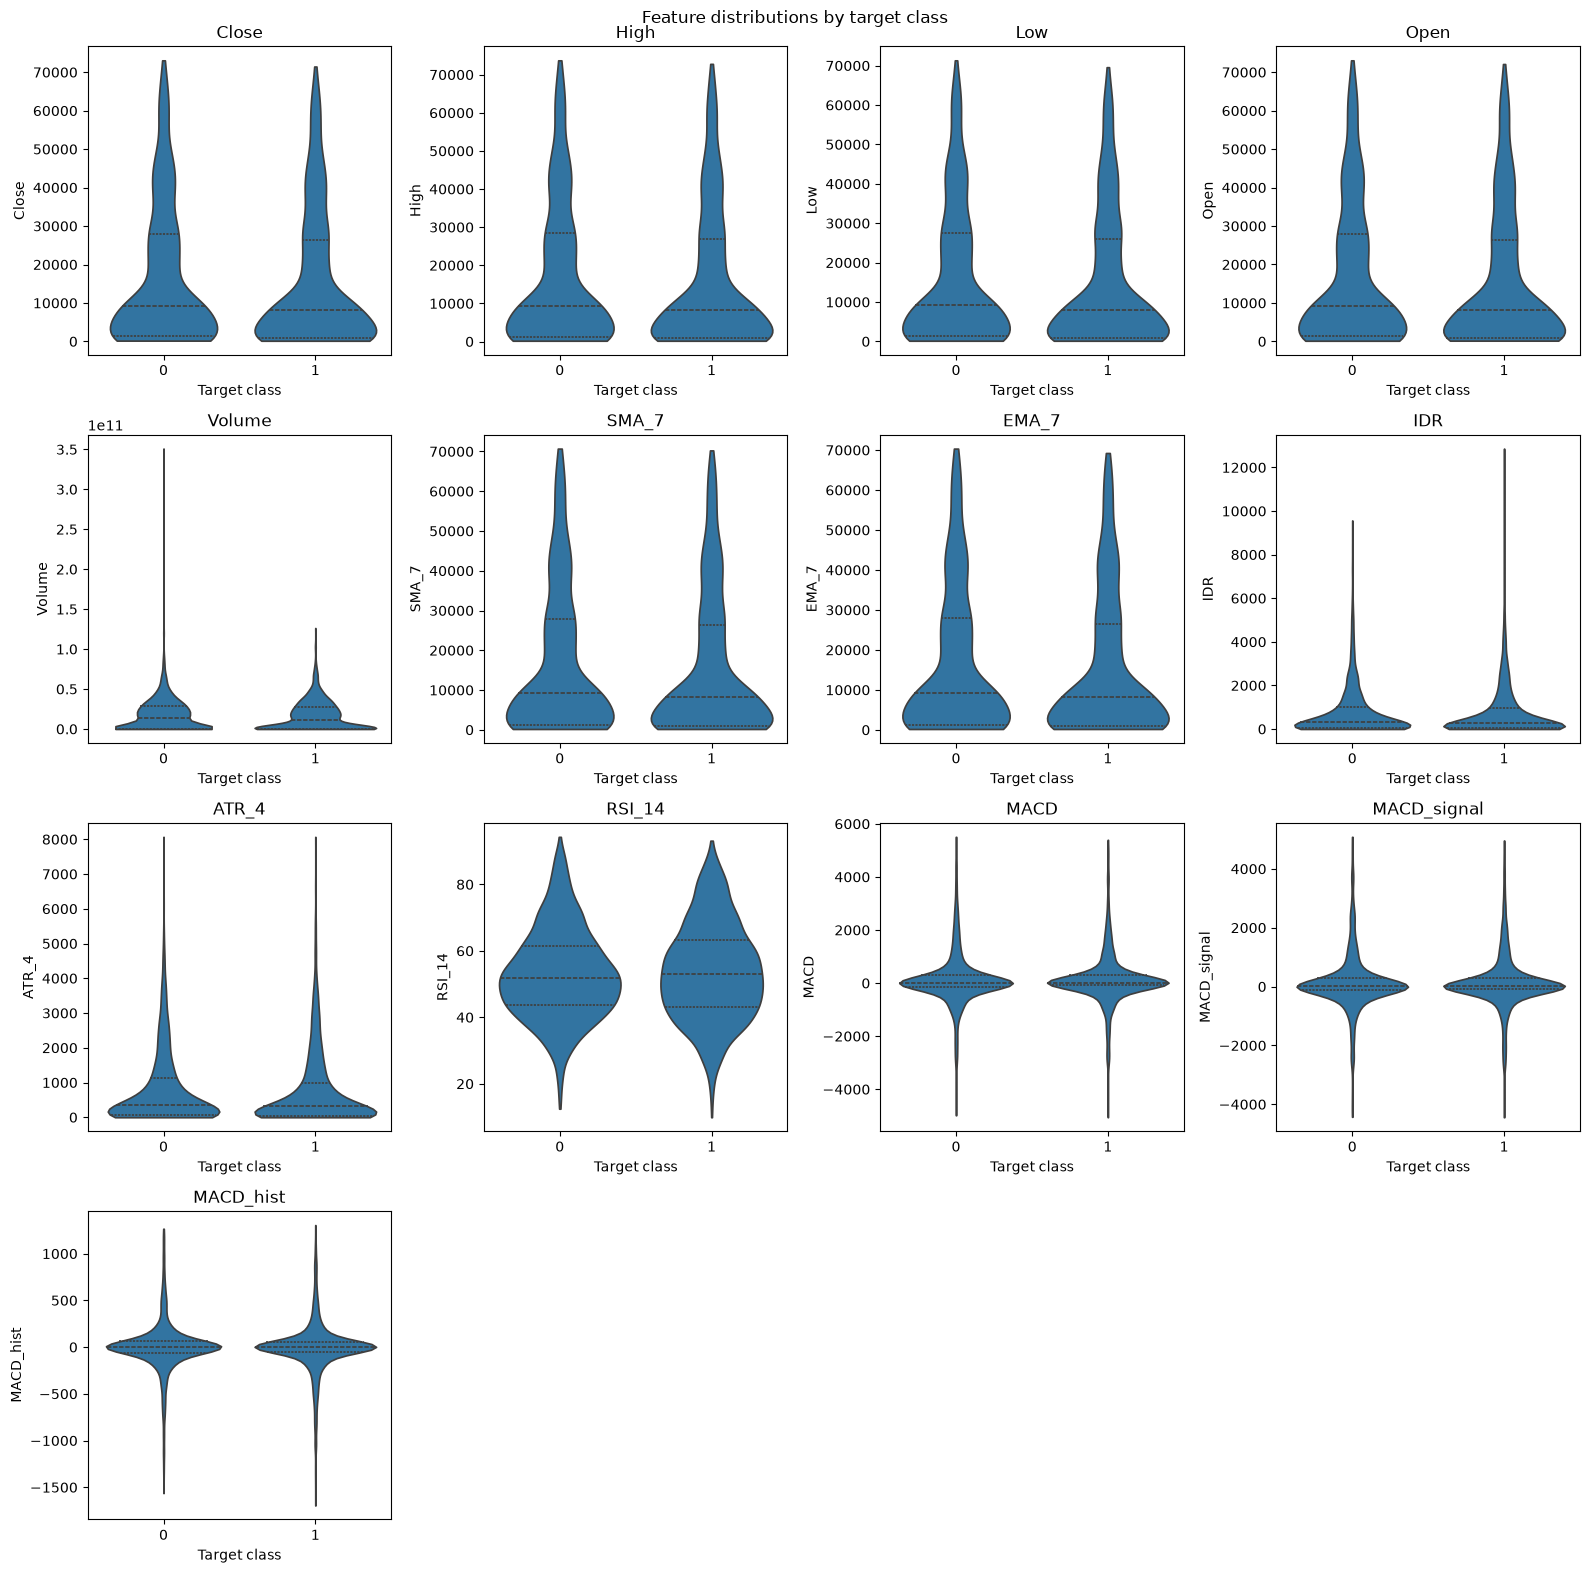

In [33]:
# Violin plots:
ncols = 4
nrows = (len(features) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4 * nrows))
axes = np.asarray(axes).ravel()

for ax, feature in zip(axes, features):
    sns.violinplot(data=fs_data, x="Direction_1", y=feature, ax=ax, inner="quartile", cut=0)
    ax.set_title(feature)
    ax.set_xlabel("Target class")
    ax.set_ylabel(feature)

for ax in axes[len(features):]:
    ax.set_visible(False)

fig.suptitle("Feature distributions by target class")
fig.tight_layout()
plt.show()

Very dificult to spot any variance in features between the two possible classes visually.

*Correlation: Eta Squared*

In [51]:
def eta_squared(categories: pd.Series, values: pd.Series) -> float:
    """Calculate eta-squared for a categorical target and numeric feature."""

    categories = pd.Series(categories)
    values = pd.Series(values)

    valid = categories.notna() & values.notna()
    categories = categories.loc[valid]
    values = values.loc[valid]

    if values.empty:
        return np.nan

    overall_mean = values.mean()

    ss_between = 0.0

    for category in categories.unique():
        group = values.loc[categories == category]

        ss_between += len(group) * (
            group.mean() - overall_mean
        ) ** 2

    ss_total = ((values - overall_mean) ** 2).sum()

    if ss_total == 0:
        return 0.0

    return ss_between / ss_total

eta_results_1 = pd.Series(
    {
        feature: eta_squared(
            fs_data['Direction_1'],
            fs_data[feature],
        )
        for feature in features
    },
    name="eta_squared",
).sort_values(ascending=False)

print(eta_results_1)

Close          1.949848e-03
Low            1.912374e-03
High           1.813669e-03
EMA_7          1.798190e-03
SMA_7          1.775885e-03
Open           1.753785e-03
Volume         1.233386e-03
ATR_4          7.842333e-04
RSI_14         6.144319e-04
MACD_hist      2.403905e-04
IDR            2.365250e-04
MACD           2.268633e-05
MACD_signal    3.578904e-07
Name: eta_squared, dtype: float64


What if 'Direction_1' was changed to something like 'Direction_5' or 'Direction_7' (i.e. 5 and 7 days ahead, respectively)?

It's easy to implement Direction_5 / Direction_7 features from 'X' using the above 'add_direction()' function

In [57]:
X_y_5 = add_direction(X, 5, "Close")
X_y_7 = add_direction(X, 7, "Close")
X_y_14 = add_direction(X, 14, "Close")
X_y_20 = add_direction(X, 20, "Close")
X_y_5 = X_y_5.dropna()
X_y_7 = X_y_7.dropna()
X_y_14 = X_y_14.dropna()
X_y_20 = X_y_20.dropna()

In [53]:
eta_results_5 = pd.Series(
    {
        feature: eta_squared(
            X_y_5['Direction_5'],
            X_y_5[feature],
        )
        for feature in features
    },
    name="eta_squared",
).sort_values(ascending=False)

print(eta_results_5)

Close          0.003720
Low            0.003666
Open           0.003630
High           0.003620
EMA_7          0.003615
SMA_7          0.003597
ATR_4          0.001870
IDR            0.001244
Volume         0.000871
RSI_14         0.000772
MACD_hist      0.000477
MACD_signal    0.000021
MACD           0.000003
Name: eta_squared, dtype: float64


In [54]:
eta_results_7 = pd.Series(
    {
        feature: eta_squared(
            X_y_7['Direction_7'],
            X_y_7[feature],
        )
        for feature in features
    },
    name="eta_squared",
).sort_values(ascending=False)

print(eta_results_7)

Low            0.003687
Close          0.003687
EMA_7          0.003666
SMA_7          0.003642
Open           0.003624
High           0.003609
RSI_14         0.002398
ATR_4          0.002245
Volume         0.001542
IDR            0.000895
MACD_signal    0.000492
MACD           0.000403
MACD_hist      0.000013
Name: eta_squared, dtype: float64


In [56]:
eta_results_14 = pd.Series(
    {
        feature: eta_squared(
            X_y_14['Direction_14'],
            X_y_14[feature],
        )
        for feature in features
    },
    name="eta_squared",
).sort_values(ascending=False)

print(eta_results_14)

ATR_4          0.009503
SMA_7          0.008567
EMA_7          0.008559
High           0.008478
Close          0.008438
Open           0.008409
Low            0.008314
IDR            0.007137
RSI_14         0.006686
Volume         0.005198
MACD           0.000782
MACD_signal    0.000637
MACD_hist      0.000205
Name: eta_squared, dtype: float64


In [58]:
eta_results_20 = pd.Series(
    {
        feature: eta_squared(
            X_y_20['Direction_20'],
            X_y_20[feature],
        )
        for feature in features
    },
    name="eta_squared",
).sort_values(ascending=False)

print(eta_results_20)

EMA_7          0.014283
SMA_7          0.014203
Close          0.014131
High           0.014107
Open           0.014006
Low            0.013981
ATR_4          0.012722
IDR            0.009278
Volume         0.007973
RSI_14         0.004879
MACD           0.002621
MACD_hist      0.002138
MACD_signal    0.001637
Name: eta_squared, dtype: float64


Longer timeframes looking ahead give a greater separability...